In [ ]:
# pipenv install pandas scipy optuna shap plotly scikit-learn matplotlib numpy ipywidgets ipykernel nbformat

# EDA
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import plotly.express as px

# ML
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss, roc_curve, roc_auc_score, f1_score, precision_score

# Hyperparams optimization
# import optuna

# Data Preparation

In [2]:
# Load dataset
df_churn = pd.read_csv('./datasets/churn_employees_dataset.csv', 
                       parse_dates=['hire_date', 'termination_date', 'last_feedback_date', 'last_raise_date', 'last_job_change_date'],
                       date_format='%Y-%m-%d')
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          2000 non-null   str           
 1   age                         2000 non-null   int64         
 2   gender                      2000 non-null   str           
 3   marital_status              2000 non-null   str           
 4   education                   2000 non-null   str           
 5   employment_status           2000 non-null   str           
 6   hire_date                   2000 non-null   datetime64[us]
 7   termination_date            286 non-null    datetime64[us]
 8   termination_type            286 non-null    str           
 9   job_title                   2000 non-null   str           
 10  current_salary              2000 non-null   int64         
 11  last_feedback_date          2000 non-null   datetime64[us]
 12  las

In [3]:
df_churn.head(10)

,id,age,gender,marital_status,education,employment_status,hire_date,termination_date,termination_type,job_title,current_salary,last_feedback_date,last_raise_date,last_job_change_date,evaluation_score,psychological_counseling,number_of_projects,number_of_clients,manager_satisfaction_level,churn
0,EMP1564,37,F,Divorced,Master,Remote,2020-01-02,NaT,NaN,Senior Developer,10207,2024-05-09,2023-07-31,2022-11-03,9.6,True,5,1,7.0,0
1,EMP0959,45,Other,Divorced,Master,Remote,2020-01-03,NaT,NaN,UX Designer,23921,2024-04-05,2023-09-10,2022-02-11,8.4,True,8,4,9.1,0
2,EMP0494,54,M,Widower/Widow,Technical Degree,Hybrid,2020-01-04,NaT,NaN,Tech Lead,15298,2023-06-16,2021-12-26,2021-05-10,8.5,False,9,7,1.3,0
3,EMP1231,44,M,Married,Bachelor,Remote,2020-01-05,NaT,NaN,QA Engineer,15306,2021-12-04,2022-01-01,2024-08-30,7.9,False,8,4,8.4,0
4,EMP1912,53,Other,Widower/Widow,PhD,In-person,2020-01-07,NaT,NaN,Senior Developer,17723,2022-03-04,2023-11-18,2024-08-08,7.5,True,5,2,8.2,0
5,EMP1053,49,Other,Married,Technical Degree,Hybrid,2020-01-08,NaT,NaN,Junior Developer,6507,2022-06-01,2020-07-05,2021-09-02,7.9,True,8,4,7.1,0
6,EMP1152,29,M,Married,PhD,In-person,2020-01-10,2022-08-22,Involuntary,Product Manager,12575,2020-10-16,2020-08-11,2022-02-27,9.1,True,6,3,1.9,1
7,EMP1317,38,F,Widower/Widow,PhD,Remote,2020-01-11,NaT,NaN,DevOps Engineer,16643,2023-03-28,2023-05-16,2022-03-28,8.9,False,6,4,8.3,0
8,EMP1398,33,M,Married,Technical Degree,Remote,2020-01-12,NaT,NaN,DevOps Engineer,16771,2024-01-03,2024-03-13,2024-06-15,7.6,False,8,1,1.2,0
9,EMP0167,23,M,Widower/Widow,PhD,Hybrid,2020-01-13,NaT,NaN,QA Engineer,13258,2022-01-02,2021-09-15,2024-04-04,8.1,True,3,6,7.0,0


## Feature Engineering

In [4]:
# Creating features based on dates

# Calculate the time at company
df_churn['time_at_company'] = df_churn.apply(lambda x: 
                                                (pd.Timestamp.now() - x['hire_date']).days if x['churn'] == 0
                                                else (x['termination_date'] - x['hire_date']).days, axis=1
                                             )

# Calculate time since last feedback
df_churn['time_since_last_feedback'] = df_churn.apply(lambda x: 
                                                         (pd.Timestamp.now() - x['last_feedback_date']).days, axis=1
                                                      )

# Calculate time since last raise
df_churn['time_since_last_raise'] = df_churn.apply(lambda x: 
                                                         (pd.Timestamp.now() - x['last_raise_date']).days, axis=1
                                                      )

# Calculate time since last job change
df_churn['time_since_last_job_change'] = df_churn.apply(lambda x: 
                                                         (pd.Timestamp.now() - x['last_job_change_date']).days, axis=1
                                                      )

df_churn.head(2)

,id,age,gender,marital_status,education,employment_status,hire_date,termination_date,termination_type,job_title,...,evaluation_score,psychological_counseling,number_of_projects,number_of_clients,manager_satisfaction_level,churn,time_at_company,time_since_last_feedback,time_since_last_raise,time_since_last_job_change
0,EMP1564,37,F,Divorced,Master,Remote,2020-01-02,NaT,NaN,Senior Developer,...,9.6,True,5,1,7.0,0,2375,786,1069,1339
1,EMP0959,45,Other,Divorced,Master,Remote,2020-01-03,NaT,NaN,UX Designer,...,8.4,True,8,4,9.1,0,2374,820,1028,1604


In [5]:
df_churn.drop(columns=['id'], inplace=True)

## EDA

In [6]:
print("Null countdown per column")
df_churn.isnull().sum()

Null countdown per column


age                              0
gender                           0
marital_status                   0
education                        0
employment_status                0
hire_date                        0
termination_date              1714
termination_type              1714
job_title                        0
current_salary                   0
last_feedback_date               0
last_raise_date                  0
last_job_change_date             0
evaluation_score                 0
psychological_counseling         0
number_of_projects               0
number_of_clients                0
manager_satisfaction_level       0
churn                            0
time_at_company                  0
time_since_last_feedback         0
time_since_last_raise            0
time_since_last_job_change       0
dtype: int64

In [7]:
# Distribution target feature (Churn)

fig = px.bar(df_churn['churn'].value_counts() / len(df_churn) * 100,
             title='Churn Factor',
             labels={'index': 'Churn', 'value': 'Percentual'})

fig.update_layout(showlegend=False)
fig.show()

In [8]:
# Possible values for each categorical column
for col in df_churn.select_dtypes(include=['str']).columns:
    print(f'\nUnique Values in {col}:')
    print(f'{df_churn[col].unique()}')


Unique Values in gender:
<StringArray>
['F', 'Other', 'M']
Length: 3, dtype: str

Unique Values in marital_status:
<StringArray>
['Divorced', 'Widower/Widow', 'Married', 'Single']
Length: 4, dtype: str

Unique Values in education:
<StringArray>
['Master', 'Technical Degree', 'Bachelor', 'PhD']
Length: 4, dtype: str

Unique Values in employment_status:
<StringArray>
['Remote', 'Hybrid', 'In-person']
Length: 3, dtype: str

Unique Values in termination_type:
<StringArray>
[nan, 'Involuntary', 'Volunteer']
Length: 3, dtype: str

Unique Values in job_title:
<StringArray>
['Senior Developer',      'UX Designer',        'Tech Lead',
      'QA Engineer', 'Junior Developer',  'Product Manager',
  'DevOps Engineer',   'Data Scientist']
Length: 8, dtype: str


In [9]:
# Descritive stats for numeric features
df_churn.select_dtypes(include=['int64', 'float64']).describe()

,age,current_salary,evaluation_score,number_of_projects,number_of_clients,manager_satisfaction_level,churn,time_at_company,time_since_last_feedback,time_since_last_raise,time_since_last_job_change
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.00000,2000.000000,2000.000000
mean,37.938500,14801.834500,7.997550,4.984500,3.998500,5.492450,0.14300,1389.888000,1105.89900,1119.005000,1106.136500
std,9.456132,5763.451836,1.157324,2.593188,1.987076,2.609817,0.35016,589.640425,395.59628,397.623967,395.911115
min,22.000000,5016.000000,6.000000,1.000000,1.000000,1.000000,0.00000,34.000000,619.00000,620.000000,619.000000
25%,30.000000,9844.250000,7.000000,3.000000,2.000000,3.300000,0.00000,966.750000,775.75000,781.750000,779.750000
50%,38.000000,14822.500000,8.000000,5.000000,4.000000,5.500000,0.00000,1416.000000,1004.50000,1019.000000,996.000000
75%,46.000000,19702.500000,9.000000,7.000000,6.000000,7.700000,0.00000,1884.500000,1345.25000,1378.250000,1339.000000
max,54.000000,24988.000000,10.000000,9.000000,7.000000,10.000000,1.00000,2375.000000,2338.00000,2291.000000,2331.000000


### Numeric features correlation with target (churn)

In [10]:
for col in df_churn.select_dtypes(include=['int64', 'float64']).columns:
    if col != 'churn':
        fig = px.box(df_churn, x='churn', y=col, title=f'Boxplot {col} X churn', color='churn')
        fig.show()

In [16]:
numeric_features = df_churn.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_churn[numeric_features].corr()

fig = px.imshow(corr_matrix,
                title="Correlation Matrix",
                color_continuous_scale='Viridis',
                zmax=1,
                zmin=-1)

fig.update_traces(text=corr_matrix, texttemplate='%{text:.1%}', textfont={'size': 9})
fig.update_layout(
    width=1000,
    height=600,
    title_font=dict(size=14),
    font=dict(size=10)
)

fig.show()


In [17]:
fig = px.scatter_matrix(df_churn, dimensions=numeric_features, color='churn', title="Dispersion Matrix")
fig.update_layout(
    width=1200,
    height=1000,
    title_font=dict(size=14),
    font=dict(size=9)
)

fig.show()

### Hypothesis test for Categorical features vs Churn

In [18]:
categorical_features = numeric_features = df_churn.select_dtypes(include=['str']).columns
for col in categorical_features:
    contingency_table = pd.crosstab(df_churn['churn'], df_churn[col])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"\nChi-Square Test for {col} VS Churn")
    print(f"p-value: {p_value}")
    if(p_value <= 0.05):
        print(f"The features {col} and Churn aren't independent")
    else:
        print(f"The features {col} and Churn are independent")


Chi-Square Test for gender VS Churn
p-value: 0.6391382063144609
The features gender and Churn are independent

Chi-Square Test for marital_status VS Churn
p-value: 0.8332629331272039
The features marital_status and Churn are independent

Chi-Square Test for education VS Churn
p-value: 0.20475149121388256
The features education and Churn are independent

Chi-Square Test for employment_status VS Churn
p-value: 0.9751275918764937
The features employment_status and Churn are independent

Chi-Square Test for termination_type VS Churn
p-value: 1.0
The features termination_type and Churn are independent

Chi-Square Test for job_title VS Churn
p-value: 0.4586024122014404
The features job_title and Churn are independent


In [20]:
for col in categorical_features:
    fig = px.histogram(df_churn, x=col, color='churn', barmode='group', title=f'{col} distribution per Churn')
    fig.show()

# Model Training

## Preparing the dataset

In [21]:
# Splitting features and target
date_features = list(df_churn.select_dtypes(include=['datetime64']).columns)

X = df_churn.drop(['churn', 'termination_type'] + date_features, axis=1)
y = df_churn['churn']

In [23]:
# Creating the preprocessor
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['str']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.5, random_state=42, shuffle=True)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Baseline Model

### Training

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    max_features='sqrt',
    class_weight='balanced'
)

In [27]:
rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

### Result Analysis

In [28]:
# Making predictions (0 or 1)
y_pred = rf_model.predict(X_test)

y_pred

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,

In [ ]:
# Returning the probability from predictions
y_pred_proba = rf_model.predict_proba(X_test)
y_pred_proba

array([[0.34, 0.66],
       [0.84, 0.16],
       [1.  , 0.  ],
       ...,
       [0.96, 0.04],
       [0.94, 0.06],
       [0.95, 0.05]], shape=(1000, 2))

In [30]:
# Model valuation
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       849
           1       1.00      0.84      0.91       151

    accuracy                           0.98      1000
   macro avg       0.99      0.92      0.95      1000
weighted avg       0.98      0.98      0.98      1000



In [32]:
# ROC curve values - TPR vs FPR and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])

In [31]:
# Calculate AUC
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

In [35]:
fig = px.area(
    x=fpr,
    y=tpr,
    title=f'ROC Curve (AUC={roc_auc:.4f})',
    labels=dict(x='False Positive Rate', y='True Positive Rate'),
    width=700, 
    height=500
)

fig.add_shape(
    type='line', line=dict(dash='dash'),
    x0=0, x1=1, y0=0, y1=1
)

fig.update_xaxes(constrain='domain')
fig.update_yaxes(scaleanchor='x', scaleratio=1)
fig.show()

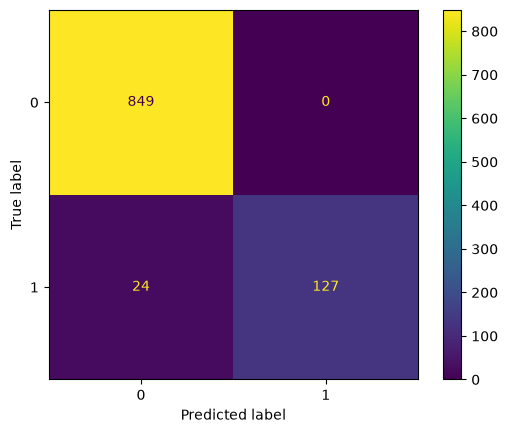

In [36]:
# Showing the confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
fig = ConfusionMatrixDisplay(conf_matrix)

fig.plot()

In [37]:
# Calculating the Log Loss
print(f'Log loss: {log_loss(y_test, y_pred_proba):.4f}')

Log loss: 0.1449


## Optimized Model (CrossValidation & Hyperparams Tuning)

### Training

In [40]:
# Creating a dict with hyperparameters values to be tested
params_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
}

In [41]:
# Configurate the GridSeachCV with 5 folds (with StratifiedKfold) using Recall as validation metric
rf_model_cv = RandomForestClassifier(class_weight='balanced', max_features='sqrt', random_state=42)
kfolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(rf_model_cv, param_grid=params_grid, cv=kfolds, scoring='recall', verbose=2)

In [42]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_de

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metric

### Result Analysis

In [45]:
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

In [46]:
best_params 

{'max_depth': 10,
 'min_samples_leaf': 5,
 'min_samples_split': 20,
 'n_estimators': 100}

In [47]:
# Returning the best score
best_score = grid_search.best_score_
best_score

np.float64(0.9259259259259259)

In [48]:
# Making predictions (0 or 1)
y_pred = best_model.predict(X_test)

y_pred

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,

In [49]:
# Returning the probability from predictions
y_pred_proba = best_model.predict_proba(X_test)
y_pred_proba

array([[0.3181294 , 0.6818706 ],
       [0.69822586, 0.30177414],
       [0.92696615, 0.07303385],
       ...,
       [0.91991986, 0.08008014],
       [0.89973613, 0.10026387],
       [0.89019058, 0.10980942]], shape=(1000, 2))

In [50]:
# Model valuation
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       849
           1       1.00      0.89      0.94       151

    accuracy                           0.98      1000
   macro avg       0.99      0.95      0.97      1000
weighted avg       0.98      0.98      0.98      1000



In [51]:
# ROC curve values - TPR vs FPR and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])

In [52]:
# Calculate AUC
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

In [53]:
fig = px.area(
    x=fpr,
    y=tpr,
    title=f'ROC Curve (AUC={roc_auc:.4f})',
    labels=dict(x='False Positive Rate', y='True Positive Rate'),
    width=700, 
    height=500
)

fig.add_shape(
    type='line', line=dict(dash='dash'),
    x0=0, x1=1, y0=0, y1=1
)

fig.update_xaxes(constrain='domain')
fig.update_yaxes(scaleanchor='x', scaleratio=1)
fig.show()

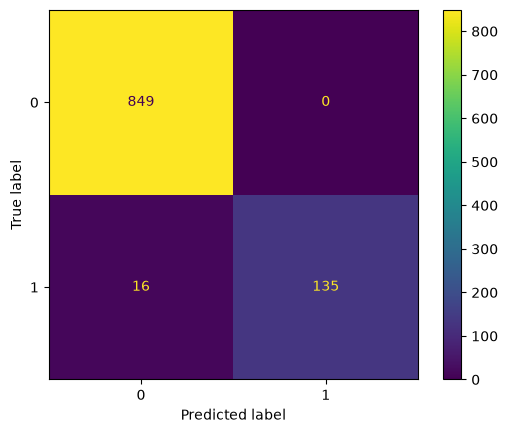

In [54]:
# Showing the confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
fig = ConfusionMatrixDisplay(conf_matrix)

fig.plot()

In [55]:
# Calculating the Log Loss
print(f'Log loss: {log_loss(y_test, y_pred_proba):.4f}')

Log loss: 0.2264
